# Phase 5.8 -- NBM vs LSTM-Autoencoder Comparison

**Objective:** Compare the Normal Behavior Model (LightGBM residual-based) and the LSTM-Autoencoder approaches for anomaly detection. Determine which method detects which fault types better, and quantify their complementarity to inform Phase 6 TDI weighting.

**Data sources:**
- `residuals_summary.json` -- per-event, per-subsystem NBM residuals in prediction window
- `ae_reconstruction_summary.json` -- per-event AE reconstruction error in prediction window
- `classification_results.json` -- NBM-based event-level predictions (Phase 4.6)
- `unified_events.csv` -- event labels, descriptions, farms

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)

PROJECT = Path(r"D:/Personal Projects/Enbridge Case Compettion")
REPORTS = PROJECT / "outputs" / "reports"
FIGURES = PROJECT / "outputs" / "figures"

# Load all data sources
with open(REPORTS / "residuals_summary.json") as f:
    residuals = json.load(f)

with open(REPORTS / "ae_reconstruction_summary.json") as f:
    ae_summary = json.load(f)

with open(REPORTS / "classification_results.json") as f:
    classification = json.load(f)

with open(REPORTS / "threshold_calibration_results.json") as f:
    threshold_cal = json.load(f)

with open(REPORTS / "aggregated_scoring_results.json") as f:
    agg_scoring = json.load(f)

events_df = pd.read_csv(PROJECT / "data" / "processed" / "unified_events.csv")
print(f"Loaded {len(events_df)} events: {events_df['event_label'].value_counts().to_dict()}")
print(f"Farms: {events_df['farm'].value_counts().to_dict()}")

Loaded 95 events: {'normal': 50, 'anomaly': 45}
Farms: {'C': 58, 'A': 22, 'B': 15}


## 1. Build unified event-level comparison table

For each event, compute:
- **NBM score:** max absolute residual across all subsystems in the prediction window (from Phase 4.4 threshold approach)
- **NBM aggregated score:** the weighted score from Phase 4.5
- **AE score:** mean reconstruction error in prediction window
- **NBM detected:** using the Phase 4.6 classification result (union strategy)
- **AE detected:** mean reconstruction error exceeds the 95th percentile of normal events' errors

In [2]:
##############################################################################
# Build a unified DataFrame: one row per event with both NBM + AE scores
##############################################################################
rows = []

# --- NBM: per-event max absolute residual across subsystems (prediction window) ---
for farm in ["A", "B", "C"]:
    if farm not in residuals:
        continue
    for event_id_str, subs_dict in residuals[farm].items():
        event_id = int(event_id_str)
        max_abs = max(abs(v["max_residual"]) for v in subs_dict.values())
        mean_abs = np.mean([abs(v["mean_residual"]) for v in subs_dict.values()])
        rows.append({
            "farm": farm,
            "event_id": event_id,
            "nbm_max_abs_residual": max_abs,
            "nbm_mean_abs_residual": mean_abs,
        })

nbm_df = pd.DataFrame(rows)

# --- AE: per-event reconstruction error (prediction window) ---
ae_events = ae_summary["per_event"]
ae_df = pd.DataFrame(ae_events)[
    ["farm", "event_id", "event_label", "event_description",
     "pred_mean_error", "pred_max_error", "pred_std_error"]
].rename(columns={
    "pred_mean_error": "ae_pred_mean",
    "pred_max_error": "ae_pred_max",
    "pred_std_error": "ae_pred_std",
})

# --- NBM classification (Phase 4.6) ---
nbm_preds = pd.DataFrame(classification["per_event_predictions"])[
    ["farm", "event_id", "true_label", "predicted_label", "aggregated_score", "confidence"]
].rename(columns={
    "predicted_label": "nbm_predicted",
    "aggregated_score": "nbm_agg_score",
    "confidence": "nbm_confidence",
})

# --- Merge everything ---
df = events_df[["farm", "event_id", "event_label", "event_description"]].copy()
df = df.merge(nbm_df, on=["farm", "event_id"], how="left")
df = df.merge(ae_df[["farm", "event_id", "ae_pred_mean", "ae_pred_max", "ae_pred_std"]],
              on=["farm", "event_id"], how="left")
df = df.merge(nbm_preds[["farm", "event_id", "nbm_predicted", "nbm_agg_score", "nbm_confidence"]],
              on=["farm", "event_id"], how="left")

# Binary labels
df["is_anomaly"] = (df["event_label"] == "anomaly").astype(int)

# --- NBM detection: use the Phase 4.6 classification result ---
df["nbm_detected"] = (df["nbm_predicted"] == "anomaly").astype(int)

# --- AE detection: 95th percentile of normal events' reconstruction errors ---
normal_ae_errors = df.loc[df["is_anomaly"] == 0, "ae_pred_mean"].dropna()
ae_threshold_95 = np.percentile(normal_ae_errors, 95)
print(f"AE detection threshold (95th pctl of normal events): {ae_threshold_95:.4f}")

df["ae_detected"] = (df["ae_pred_mean"] > ae_threshold_95).astype(int)

print(f"\nUnified table: {len(df)} events")
print(f"NBM detections: {df['nbm_detected'].sum()}")
print(f"AE detections: {df['ae_detected'].sum()}")
df.head(10)

AE detection threshold (95th pctl of normal events): 0.5269

Unified table: 95 events
NBM detections: 55
AE detections: 22


,farm,event_id,event_label,event_description,nbm_max_abs_residual,nbm_mean_abs_residual,ae_pred_mean,ae_pred_max,ae_pred_std,nbm_predicted,nbm_agg_score,nbm_confidence,is_anomaly,nbm_detected,ae_detected
0,A,68,anomaly,Transformer failure,23.876643,2.139882,0.322193,1.687764,0.350641,normal,0.7149,-0.7078,1,0,0
1,A,22,anomaly,Hydraulic group,23.419580,1.258054,0.328850,0.953104,0.244543,normal,2.0668,-0.8105,1,0,0
2,A,72,anomaly,Gearbox failure,21.201219,1.748911,0.094131,0.580916,0.083445,anomaly,0.9420,0.0373,1,1,0
3,A,73,anomaly,Hydraulic group,33.012223,3.294092,0.484889,1.938300,0.478427,anomaly,2.0836,0.0872,1,1,0
4,A,0,anomaly,Generator bearing failure,34.898577,3.279339,0.478292,2.308534,0.504452,anomaly,2.8550,0.2313,1,1,0
5,A,26,anomaly,Hydraulic group,30.378076,1.914023,0.124641,0.923812,0.167247,anomaly,0.6255,0.0755,1,1,0
6,A,40,anomaly,Generator bearing failure,183.557245,2.990020,1.118809,6.886835,1.964908,anomaly,6.2515,3.4381,1,1,1
7,A,42,anomaly,Hydraulic group,31.252848,3.937497,0.134313,0.755782,0.141883,anomaly,2.3004,0.5041,1,1,0
8,A,10,anomaly,Gearbox failure,27.373809,2.721476,0.144163,1.035677,0.166705,anomaly,1.3160,0.1014,1,1,0
9,A,45,anomaly,Hydraulic group,16.340337,1.769032,0.180094,0.574995,0.126676,anomaly,1.3003,0.0453,1,1,0


## 2. Event-Level Detection Comparison (2x2 Table)

How many events does each method catch, and do they overlap?

DETECTION OVERLAP -- ANOMALY EVENTS ONLY (n=45)
  Both detect:        18  ( 40.0%)
  NBM only:           21  ( 46.7%)
  AE only:             1  (  2.2%)
  Both miss:           5  ( 11.1%)
------------------------------------------------------------
  NBM detection rate:  86.7%
  AE detection rate:   42.2%
  Union (either):      88.9%
  Intersection (both): 40.0%

FALSE ALARMS (normal events flagged):
  NBM false alarms:  16/50 (32.0%)
  AE false alarms:   3/50 (6.0%)
  Both flag (AND):   3/50 (6.0%)


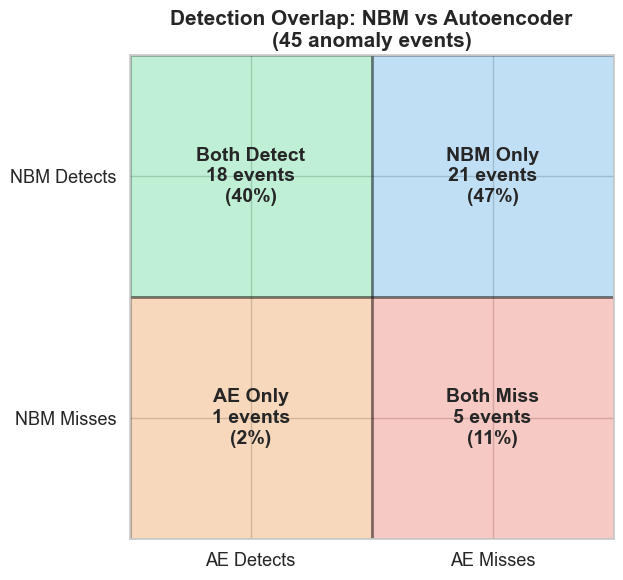


Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\nbm_vs_ae_detection_overlap.png


In [3]:
##############################################################################
# 2x2 detection overlap -- among TRUE ANOMALIES only
##############################################################################
anomalies = df[df["is_anomaly"] == 1].copy()
normals = df[df["is_anomaly"] == 0].copy()

both_detect = ((anomalies["nbm_detected"] == 1) & (anomalies["ae_detected"] == 1)).sum()
nbm_only    = ((anomalies["nbm_detected"] == 1) & (anomalies["ae_detected"] == 0)).sum()
ae_only     = ((anomalies["nbm_detected"] == 0) & (anomalies["ae_detected"] == 1)).sum()
both_miss   = ((anomalies["nbm_detected"] == 0) & (anomalies["ae_detected"] == 0)).sum()

print("=" * 60)
print("DETECTION OVERLAP -- ANOMALY EVENTS ONLY (n=45)")
print("=" * 60)
print(f"  Both detect:       {both_detect:3d}  ({both_detect/len(anomalies)*100:5.1f}%)")
print(f"  NBM only:          {nbm_only:3d}  ({nbm_only/len(anomalies)*100:5.1f}%)")
print(f"  AE only:           {ae_only:3d}  ({ae_only/len(anomalies)*100:5.1f}%)")
print(f"  Both miss:         {both_miss:3d}  ({both_miss/len(anomalies)*100:5.1f}%)")
print("-" * 60)
print(f"  NBM detection rate:  {(both_detect+nbm_only)/len(anomalies)*100:.1f}%")
print(f"  AE detection rate:   {(both_detect+ae_only)/len(anomalies)*100:.1f}%")
print(f"  Union (either):      {(both_detect+nbm_only+ae_only)/len(anomalies)*100:.1f}%")
print(f"  Intersection (both): {both_detect/len(anomalies)*100:.1f}%")

# Also show false alarms
nbm_fa = normals["nbm_detected"].sum()
ae_fa = normals["ae_detected"].sum()
both_fa = ((normals["nbm_detected"] == 1) & (normals["ae_detected"] == 1)).sum()

print(f"\nFALSE ALARMS (normal events flagged):")
print(f"  NBM false alarms:  {nbm_fa}/{len(normals)} ({nbm_fa/len(normals)*100:.1f}%)")
print(f"  AE false alarms:   {ae_fa}/{len(normals)} ({ae_fa/len(normals)*100:.1f}%)")
print(f"  Both flag (AND):   {both_fa}/{len(normals)} ({both_fa/len(normals)*100:.1f}%)")

# Visualize the 2x2 matrix
fig, ax = plt.subplots(figsize=(8, 6))
matrix = np.array([[both_detect, nbm_only], [ae_only, both_miss]])
labels = np.array([
    [f"Both Detect\n{both_detect} events\n({both_detect/len(anomalies)*100:.0f}%)",
     f"NBM Only\n{nbm_only} events\n({nbm_only/len(anomalies)*100:.0f}%)"],
    [f"AE Only\n{ae_only} events\n({ae_only/len(anomalies)*100:.0f}%)",
     f"Both Miss\n{both_miss} events\n({both_miss/len(anomalies)*100:.0f}%)"]
])

colors = np.array([["#2ecc71", "#3498db"], ["#e67e22", "#e74c3c"]])
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1-i), 1, 1, fill=True,
                                    facecolor=colors[i, j], alpha=0.3, edgecolor="black", lw=2))
        ax.text(j + 0.5, 1.5 - i, labels[i, j], ha="center", va="center",
                fontsize=14, fontweight="bold")

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["AE Detects", "AE Misses"], fontsize=13)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["NBM Misses", "NBM Detects"], fontsize=13)
ax.set_title("Detection Overlap: NBM vs Autoencoder\n(45 anomaly events)", fontsize=15, fontweight="bold")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(FIGURES / "nbm_vs_ae_detection_overlap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {FIGURES / 'nbm_vs_ae_detection_overlap.png'}")

## 3. Per-Fault-Type Comparison

Group anomaly events by fault category and compare detection rates.

In [4]:
##############################################################################
# Categorize fault types from event descriptions
##############################################################################
def categorize_fault(desc):
    """Map raw event descriptions to human-readable fault categories."""
    if pd.isna(desc) or desc.strip() == "":
        return "Normal"
    d = desc.lower()

    if "generator bearing" in d:
        return "Generator Bearing"
    if "gearbox" in d or "gear oil" in d or "gear" in d:
        return "Gearbox"
    if "transformer" in d:
        return "Transformer"
    if "hydraulic" in d or "rotorbrake" in d or "rotor brake" in d or "accumulator" in d:
        return "Hydraulic"
    if "pitch" in d or "axis" in d or "blade" in d:
        return "Pitch System"
    if "communication" in d or "bk1120" in d or "beckhoff" in d or "slip ring" in d:
        return "Communication"
    if "rotor bearing" in d or "rotorbearing" in d or "main bearing" in d:
        return "Rotor Bearing"
    if "battery" in d or "dc-link" in d:
        return "Electrical/Battery"
    if "converter" in d or "umrichter" in d or "fuse" in d:
        return "Converter"
    if "cooling" in d or "valve" in d or "water" in d:
        return "Cooling System"
    if "oil" in d or "pump" in d:
        return "Oil/Lubrication"
    if "wec" in d or "failure" in d:
        return "General WEC Failure"
    if "grease" in d or "yaw" in d or "carbon brush" in d or "grounding" in d:
        return "Misc. Mechanical"
    if "safety" in d:
        return "Safety System"
    return "Other"

df["fault_category"] = df["event_description"].apply(categorize_fault)

# Show distribution for anomaly events only
anom = df[df["is_anomaly"] == 1].copy()
print("Fault category distribution (anomaly events):")
print(anom["fault_category"].value_counts().to_string())
print(f"\nTotal anomaly events: {len(anom)}")

Fault category distribution (anomaly events):
fault_category
Pitch System           11
Hydraulic               8
Gearbox                 6
Transformer             5
Rotor Bearing           3
Generator Bearing       2
Converter               2
General WEC Failure     2
Communication           2
Misc. Mechanical        1
Cooling System          1
Oil/Lubrication         1
Electrical/Battery      1

Total anomaly events: 45


Per-fault-type detection rates:
         Fault Type  N  NBM Detects  AE Detects  Both  Either  NBM Rate  AE Rate  Union Rate
       Pitch System 11           10           5     5      10       91%      45%         91%
          Hydraulic  8            6           1     1       6       75%      12%         75%
            Gearbox  6            6           3     3       6      100%      50%        100%
        Transformer  5            3           0     0       3       60%       0%         60%
      Rotor Bearing  3            3           2     2       3      100%      67%        100%
  Generator Bearing  2            2           1     1       2      100%      50%        100%
          Converter  2            2           2     2       2      100%     100%        100%
General WEC Failure  2            2           2     2       2      100%     100%        100%
      Communication  2            2           1     1       2      100%      50%        100%
   Misc. Mechanical  1            0   

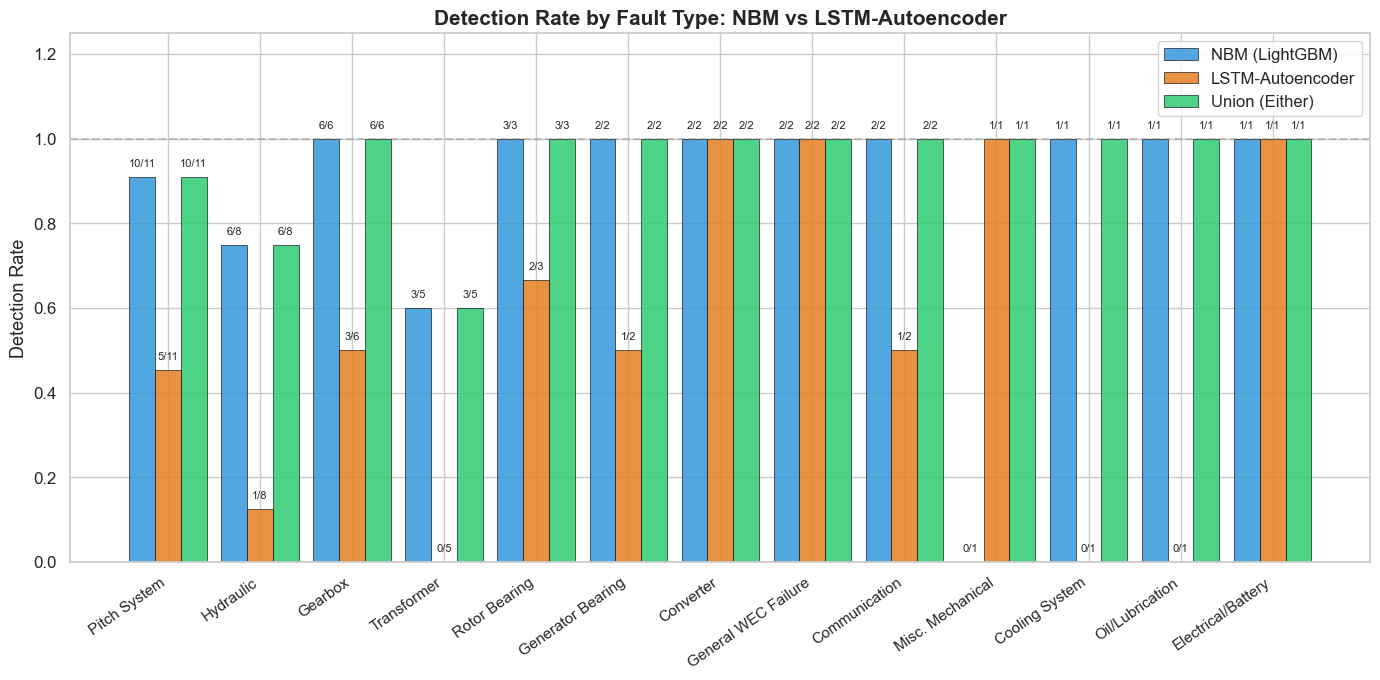


Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\nbm_vs_ae_per_fault_type.png


In [5]:
##############################################################################
# Per-fault-type detection rates: NBM vs AE
##############################################################################
fault_comparison = []
for cat in anom["fault_category"].unique():
    subset = anom[anom["fault_category"] == cat]
    n = len(subset)
    nbm_det = subset["nbm_detected"].sum()
    ae_det = subset["ae_detected"].sum()
    both = ((subset["nbm_detected"] == 1) & (subset["ae_detected"] == 1)).sum()
    either = ((subset["nbm_detected"] == 1) | (subset["ae_detected"] == 1)).sum()
    fault_comparison.append({
        "Fault Type": cat,
        "N": n,
        "NBM Detects": nbm_det,
        "AE Detects": ae_det,
        "Both": both,
        "Either": either,
        "NBM Rate": nbm_det / n if n > 0 else 0,
        "AE Rate": ae_det / n if n > 0 else 0,
        "Union Rate": either / n if n > 0 else 0,
    })

fault_comp_df = pd.DataFrame(fault_comparison).sort_values("N", ascending=False)
print("Per-fault-type detection rates:")
print(fault_comp_df.to_string(index=False, float_format=lambda x: f"{x:.0%}" if isinstance(x, float) else str(x)))

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(14, 7))
cats = fault_comp_df["Fault Type"].values
x = np.arange(len(cats))
width = 0.28

bars1 = ax.bar(x - width, fault_comp_df["NBM Rate"], width, label="NBM (LightGBM)",
               color="#3498db", alpha=0.85, edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x, fault_comp_df["AE Rate"], width, label="LSTM-Autoencoder",
               color="#e67e22", alpha=0.85, edgecolor="black", linewidth=0.5)
bars3 = ax.bar(x + width, fault_comp_df["Union Rate"], width, label="Union (Either)",
               color="#2ecc71", alpha=0.85, edgecolor="black", linewidth=0.5)

# Add count labels on bars
for i, (b1, b2, b3) in enumerate(zip(bars1, bars2, bars3)):
    n = fault_comp_df.iloc[i]["N"]
    ax.text(b1.get_x() + b1.get_width()/2, b1.get_height() + 0.02,
            f"{fault_comp_df.iloc[i]['NBM Detects']:.0f}/{n:.0f}", ha="center", va="bottom", fontsize=8)
    ax.text(b2.get_x() + b2.get_width()/2, b2.get_height() + 0.02,
            f"{fault_comp_df.iloc[i]['AE Detects']:.0f}/{n:.0f}", ha="center", va="bottom", fontsize=8)
    ax.text(b3.get_x() + b3.get_width()/2, b3.get_height() + 0.02,
            f"{fault_comp_df.iloc[i]['Either']:.0f}/{n:.0f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=35, ha="right", fontsize=11)
ax.set_ylabel("Detection Rate", fontsize=13)
ax.set_title("Detection Rate by Fault Type: NBM vs LSTM-Autoencoder", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1.25)
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES / "nbm_vs_ae_per_fault_type.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {FIGURES / 'nbm_vs_ae_per_fault_type.png'}")

## 4. Per-Farm Comparison

Detection rate and false alarm rate per farm, per method.

Per-Farm Detection & False Alarm Rates:
Farm  N Anomaly  N Normal NBM Det. Rate AE Det. Rate Union Det. Rate NBM FA Rate AE FA Rate Union FA Rate
   A         12        10         75.0%         8.3%           75.0%       10.0%       0.0%         10.0%
   B          6         9         83.3%        33.3%           83.3%       33.3%      11.1%         33.3%
   C         27        31         92.6%        59.3%           96.3%       38.7%       6.5%         38.7%


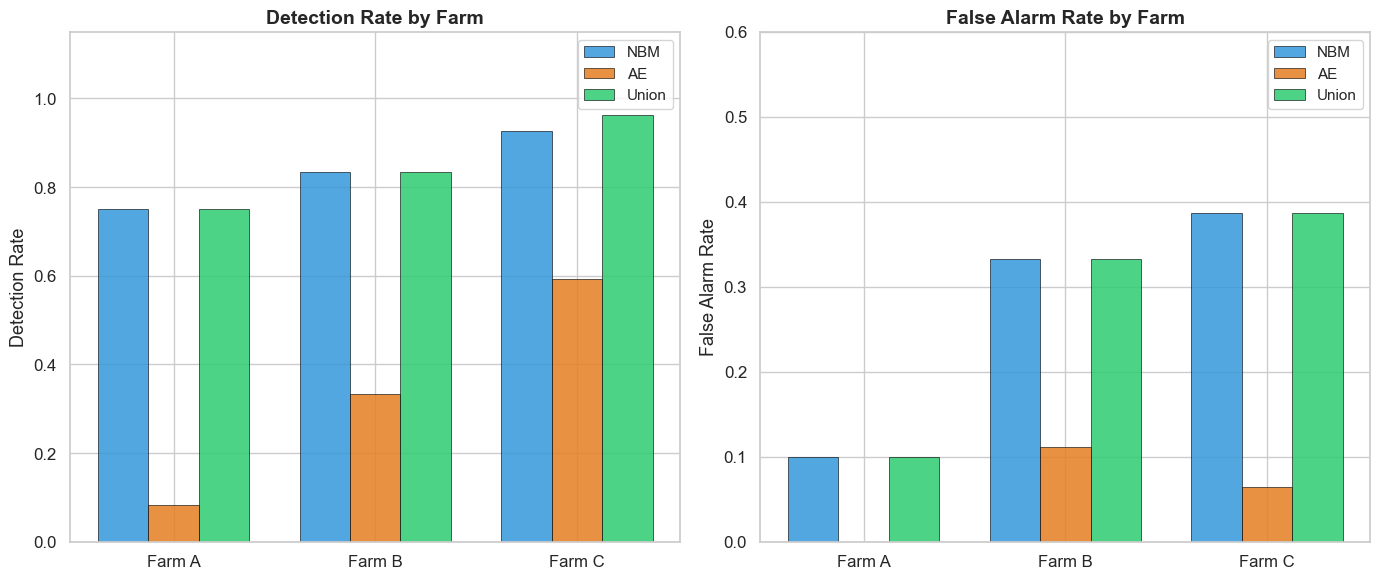


Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\nbm_vs_ae_per_farm.png


In [6]:
##############################################################################
# Per-farm detection rate and false alarm rate
##############################################################################
farm_rows = []
for farm in ["A", "B", "C"]:
    farm_anom = df[(df["farm"] == farm) & (df["is_anomaly"] == 1)]
    farm_norm = df[(df["farm"] == farm) & (df["is_anomaly"] == 0)]
    n_anom = len(farm_anom)
    n_norm = len(farm_norm)

    nbm_tp = farm_anom["nbm_detected"].sum()
    ae_tp = farm_anom["ae_detected"].sum()
    union_tp = ((farm_anom["nbm_detected"] == 1) | (farm_anom["ae_detected"] == 1)).sum()
    inter_tp = ((farm_anom["nbm_detected"] == 1) & (farm_anom["ae_detected"] == 1)).sum()

    nbm_fp = farm_norm["nbm_detected"].sum()
    ae_fp = farm_norm["ae_detected"].sum()
    union_fp = ((farm_norm["nbm_detected"] == 1) | (farm_norm["ae_detected"] == 1)).sum()
    inter_fp = ((farm_norm["nbm_detected"] == 1) & (farm_norm["ae_detected"] == 1)).sum()

    farm_rows.append({
        "Farm": farm,
        "N Anomaly": n_anom,
        "N Normal": n_norm,
        "NBM Det. Rate": nbm_tp / n_anom if n_anom else 0,
        "AE Det. Rate": ae_tp / n_anom if n_anom else 0,
        "Union Det. Rate": union_tp / n_anom if n_anom else 0,
        "NBM FA Rate": nbm_fp / n_norm if n_norm else 0,
        "AE FA Rate": ae_fp / n_norm if n_norm else 0,
        "Union FA Rate": union_fp / n_norm if n_norm else 0,
    })

farm_comp_df = pd.DataFrame(farm_rows)
print("Per-Farm Detection & False Alarm Rates:")
print("=" * 100)
fmt = {col: "{:.1%}".format for col in farm_comp_df.columns if "Rate" in col}
display_df = farm_comp_df.copy()
for col in [c for c in display_df.columns if "Rate" in c]:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.1%}")
print(display_df.to_string(index=False))

# Grouped bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

farms = farm_comp_df["Farm"].values
x = np.arange(len(farms))
w = 0.25

# Detection rates
ax1.bar(x - w, farm_comp_df["NBM Det. Rate"], w, label="NBM", color="#3498db", alpha=0.85, edgecolor="black", linewidth=0.5)
ax1.bar(x,     farm_comp_df["AE Det. Rate"],  w, label="AE",  color="#e67e22", alpha=0.85, edgecolor="black", linewidth=0.5)
ax1.bar(x + w, farm_comp_df["Union Det. Rate"], w, label="Union", color="#2ecc71", alpha=0.85, edgecolor="black", linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels([f"Farm {f}" for f in farms], fontsize=12)
ax1.set_ylabel("Detection Rate", fontsize=13)
ax1.set_title("Detection Rate by Farm", fontsize=14, fontweight="bold")
ax1.set_ylim(0, 1.15)
ax1.legend(fontsize=11)

# False alarm rates
ax2.bar(x - w, farm_comp_df["NBM FA Rate"], w, label="NBM", color="#3498db", alpha=0.85, edgecolor="black", linewidth=0.5)
ax2.bar(x,     farm_comp_df["AE FA Rate"],  w, label="AE",  color="#e67e22", alpha=0.85, edgecolor="black", linewidth=0.5)
ax2.bar(x + w, farm_comp_df["Union FA Rate"], w, label="Union", color="#2ecc71", alpha=0.85, edgecolor="black", linewidth=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels([f"Farm {f}" for f in farms], fontsize=12)
ax2.set_ylabel("False Alarm Rate", fontsize=13)
ax2.set_title("False Alarm Rate by Farm", fontsize=14, fontweight="bold")
ax2.set_ylim(0, max(farm_comp_df["Union FA Rate"].max(), 0.5) + 0.1)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES / "nbm_vs_ae_per_farm.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {FIGURES / 'nbm_vs_ae_per_farm.png'}")

## 5. Score Distribution Comparison (Violin Plots)

Side-by-side comparison of NBM aggregated score vs AE reconstruction error, colored by normal/anomaly. Shows which method provides better class separation.

C:\Users\talha\AppData\Local\Temp\ipykernel_24336\3901937947.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Label", y="nbm_agg_score", ax=ax1, palette=palette,
C:\Users\talha\AppData\Local\Temp\ipykernel_24336\3901937947.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Label", y="ae_pred_mean", ax=ax2, palette=palette,


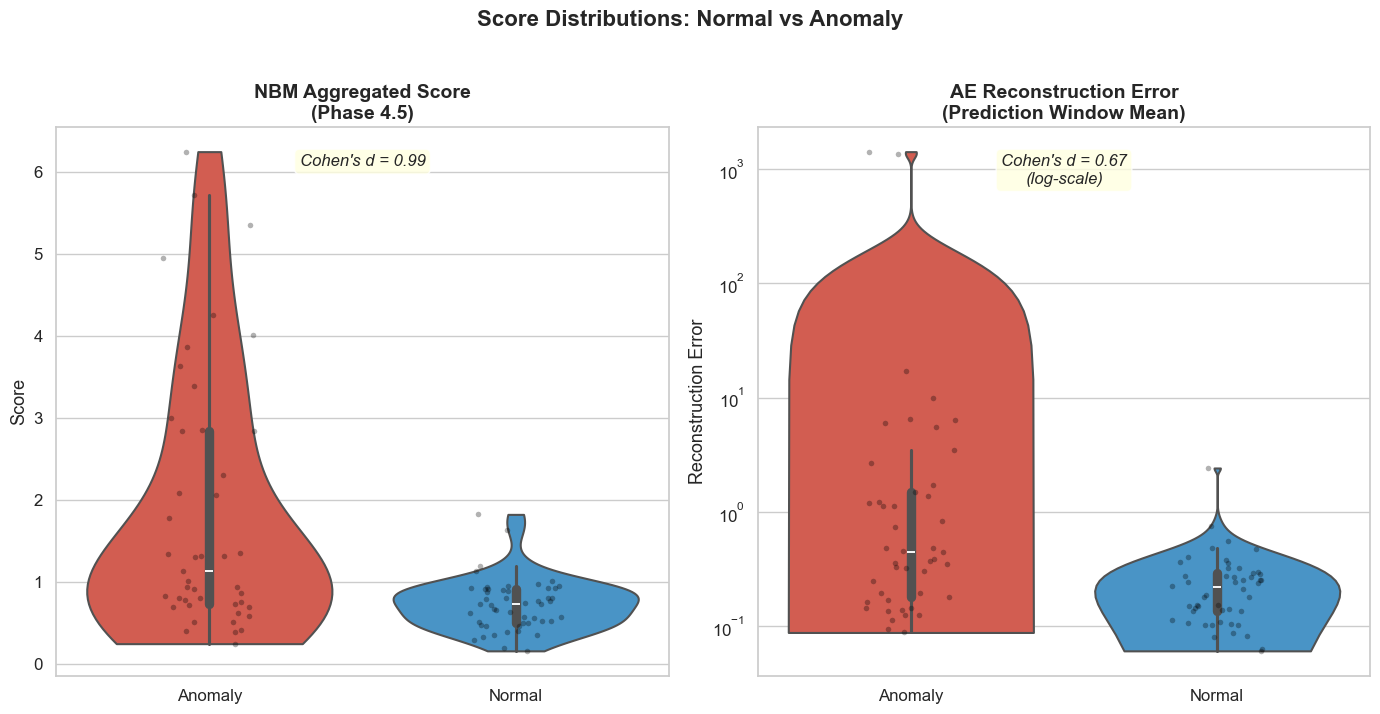


NBM Aggregated Score:
  Normal:  mean=0.727, std=0.319, median=0.732
  Anomaly: mean=1.871, std=1.605, median=1.140
  Cohen's d = 0.989

AE Reconstruction Error:
  Normal:  mean=0.273, std=0.339, median=0.218
  Anomaly: mean=63.209, std=288.348, median=0.448
  Cohen's d (log-scale) = 0.673

Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\nbm_vs_ae_score_distributions.png


In [7]:
##############################################################################
# Violin plots: NBM score vs AE score, by class
##############################################################################
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Prepare data
plot_df = df[["event_label", "nbm_agg_score", "ae_pred_mean"]].dropna().copy()
plot_df["Label"] = plot_df["event_label"].map({"normal": "Normal", "anomaly": "Anomaly"})

palette = {"Normal": "#3498db", "Anomaly": "#e74c3c"}

# NBM aggregated score
sns.violinplot(data=plot_df, x="Label", y="nbm_agg_score", ax=ax1, palette=palette,
               inner="box", cut=0, linewidth=1.5)
sns.stripplot(data=plot_df, x="Label", y="nbm_agg_score", ax=ax1,
              color="black", alpha=0.3, size=4, jitter=0.15)
ax1.set_title("NBM Aggregated Score\n(Phase 4.5)", fontsize=14, fontweight="bold")
ax1.set_ylabel("Score", fontsize=13)
ax1.set_xlabel("")

# Effect size
nbm_normal = plot_df.loc[plot_df["Label"] == "Normal", "nbm_agg_score"]
nbm_anomaly = plot_df.loc[plot_df["Label"] == "Anomaly", "nbm_agg_score"]
nbm_d = (nbm_anomaly.mean() - nbm_normal.mean()) / np.sqrt((nbm_normal.std()**2 + nbm_anomaly.std()**2) / 2)
ax1.text(0.5, 0.95, f"Cohen's d = {nbm_d:.2f}", transform=ax1.transAxes,
         ha="center", va="top", fontsize=12, style="italic",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

# AE reconstruction error -- use log scale for better visualization since Farm C dominates
# First show raw, then log
sns.violinplot(data=plot_df, x="Label", y="ae_pred_mean", ax=ax2, palette=palette,
               inner="box", cut=0, linewidth=1.5)
sns.stripplot(data=plot_df, x="Label", y="ae_pred_mean", ax=ax2,
              color="black", alpha=0.3, size=4, jitter=0.15)
ax2.set_title("AE Reconstruction Error\n(Prediction Window Mean)", fontsize=14, fontweight="bold")
ax2.set_ylabel("Reconstruction Error", fontsize=13)
ax2.set_xlabel("")
ax2.set_yscale("log")

ae_normal = plot_df.loc[plot_df["Label"] == "Normal", "ae_pred_mean"]
ae_anomaly = plot_df.loc[plot_df["Label"] == "Anomaly", "ae_pred_mean"]
# Use log-transformed values for effect size
ae_d = (np.log1p(ae_anomaly).mean() - np.log1p(ae_normal).mean()) / \
       np.sqrt((np.log1p(ae_normal).std()**2 + np.log1p(ae_anomaly).std()**2) / 2)
ax2.text(0.5, 0.95, f"Cohen's d = {ae_d:.2f}\n(log-scale)", transform=ax2.transAxes,
         ha="center", va="top", fontsize=12, style="italic",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Score Distributions: Normal vs Anomaly", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "nbm_vs_ae_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary stats
print("\nNBM Aggregated Score:")
print(f"  Normal:  mean={nbm_normal.mean():.3f}, std={nbm_normal.std():.3f}, median={nbm_normal.median():.3f}")
print(f"  Anomaly: mean={nbm_anomaly.mean():.3f}, std={nbm_anomaly.std():.3f}, median={nbm_anomaly.median():.3f}")
print(f"  Cohen's d = {nbm_d:.3f}")
print(f"\nAE Reconstruction Error:")
print(f"  Normal:  mean={ae_normal.mean():.3f}, std={ae_normal.std():.3f}, median={ae_normal.median():.3f}")
print(f"  Anomaly: mean={ae_anomaly.mean():.3f}, std={ae_anomaly.std():.3f}, median={ae_anomaly.median():.3f}")
print(f"  Cohen's d (log-scale) = {ae_d:.3f}")
print(f"\nSaved: {FIGURES / 'nbm_vs_ae_score_distributions.png'}")

## 6. Complementarity Analysis

What happens if we combine both methods? Compare OR logic (either detects) vs AND logic (both detect).

COMBINATION STRATEGIES
Strategy                 TP   FP   TN   FN  Det.Rate  FA Rate Precision     F1 Accuracy
--------------------------------------------------------------------------------
NBM Only                 39   16   34    6     86.7%    32.0%     70.9%  78.0%    76.8%
AE Only                  19    3   47   26     42.2%     6.0%     86.4%  56.7%    69.5%
Union (OR)               40   16   34    5     88.9%    32.0%     71.4%  79.2%    77.9%
Intersection (AND)       18    3   47   27     40.0%     6.0%     85.7%  54.5%    68.4%


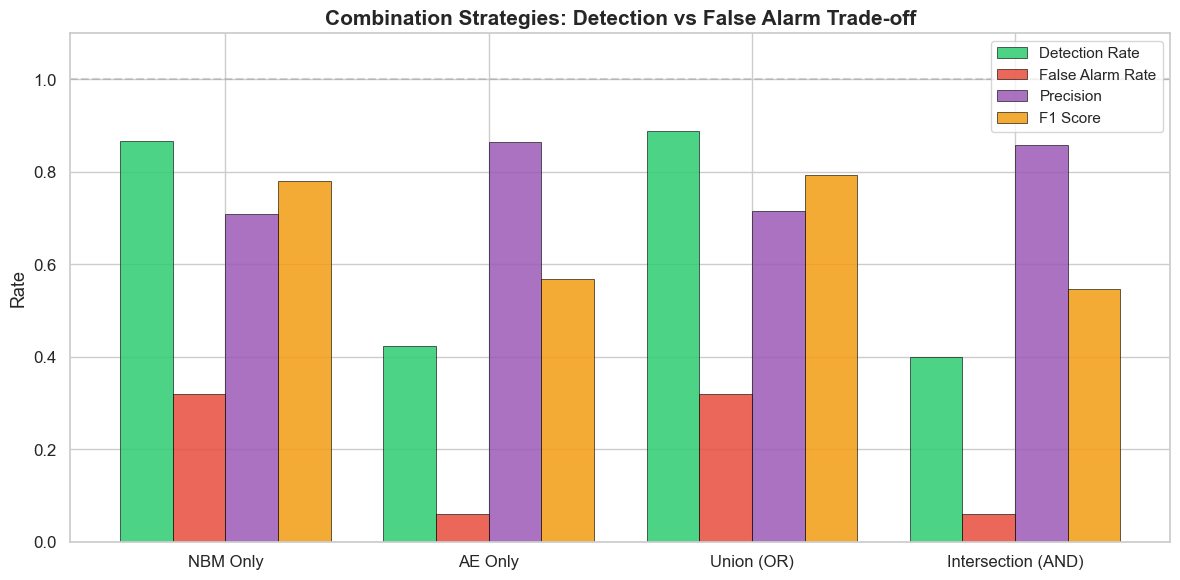


Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\nbm_vs_ae_combination_strategies.png


In [8]:
##############################################################################
# Complementarity: OR vs AND combinations
##############################################################################
n_anomaly = len(anomalies)
n_normal = len(normals)

# Individual methods
nbm_tp = anomalies["nbm_detected"].sum()
nbm_fp = normals["nbm_detected"].sum()
ae_tp = anomalies["ae_detected"].sum()
ae_fp = normals["ae_detected"].sum()

# Union (OR): flag if EITHER method detects
union_tp = ((anomalies["nbm_detected"] == 1) | (anomalies["ae_detected"] == 1)).sum()
union_fp = ((normals["nbm_detected"] == 1) | (normals["ae_detected"] == 1)).sum()

# Intersection (AND): flag only if BOTH detect
inter_tp = ((anomalies["nbm_detected"] == 1) & (anomalies["ae_detected"] == 1)).sum()
inter_fp = ((normals["nbm_detected"] == 1) & (normals["ae_detected"] == 1)).sum()

strategies = {
    "NBM Only": {"tp": nbm_tp, "fp": nbm_fp},
    "AE Only":  {"tp": ae_tp,  "fp": ae_fp},
    "Union (OR)": {"tp": union_tp, "fp": union_fp},
    "Intersection (AND)": {"tp": inter_tp, "fp": inter_fp},
}

print("=" * 80)
print("COMBINATION STRATEGIES")
print("=" * 80)
print(f"{'Strategy':<22s} {'TP':>4s} {'FP':>4s} {'TN':>4s} {'FN':>4s}  "
      f"{'Det.Rate':>8s} {'FA Rate':>8s} {'Precision':>9s} {'F1':>6s} {'Accuracy':>8s}")
print("-" * 80)

combo_rows = []
for name, vals in strategies.items():
    tp = vals["tp"]
    fp = vals["fp"]
    tn = n_normal - fp
    fn = n_anomaly - tp
    det_rate = tp / n_anomaly
    fa_rate = fp / n_normal
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * prec * det_rate / (prec + det_rate) if (prec + det_rate) > 0 else 0
    acc = (tp + tn) / (n_anomaly + n_normal)

    print(f"{name:<22s} {tp:4d} {fp:4d} {tn:4d} {fn:4d}  "
          f"{det_rate:8.1%} {fa_rate:8.1%} {prec:9.1%} {f1:6.1%} {acc:8.1%}")

    combo_rows.append({
        "Strategy": name, "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "Detection Rate": det_rate, "False Alarm Rate": fa_rate,
        "Precision": prec, "F1": f1, "Accuracy": acc,
    })

combo_df = pd.DataFrame(combo_rows)

# Visualization: comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(combo_df))
w = 0.2

ax.bar(x - 1.5*w, combo_df["Detection Rate"], w, label="Detection Rate",
       color="#2ecc71", alpha=0.85, edgecolor="black", linewidth=0.5)
ax.bar(x - 0.5*w, combo_df["False Alarm Rate"], w, label="False Alarm Rate",
       color="#e74c3c", alpha=0.85, edgecolor="black", linewidth=0.5)
ax.bar(x + 0.5*w, combo_df["Precision"], w, label="Precision",
       color="#9b59b6", alpha=0.85, edgecolor="black", linewidth=0.5)
ax.bar(x + 1.5*w, combo_df["F1"], w, label="F1 Score",
       color="#f39c12", alpha=0.85, edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(combo_df["Strategy"], fontsize=12)
ax.set_ylabel("Rate", fontsize=13)
ax.set_title("Combination Strategies: Detection vs False Alarm Trade-off", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11, loc="upper right")
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "nbm_vs_ae_combination_strategies.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {FIGURES / 'nbm_vs_ae_combination_strategies.png'}")

## 7. Scatter Plot: NBM Score vs AE Score (per event)

Shows the correlation between the two methods -- are they redundant or complementary?

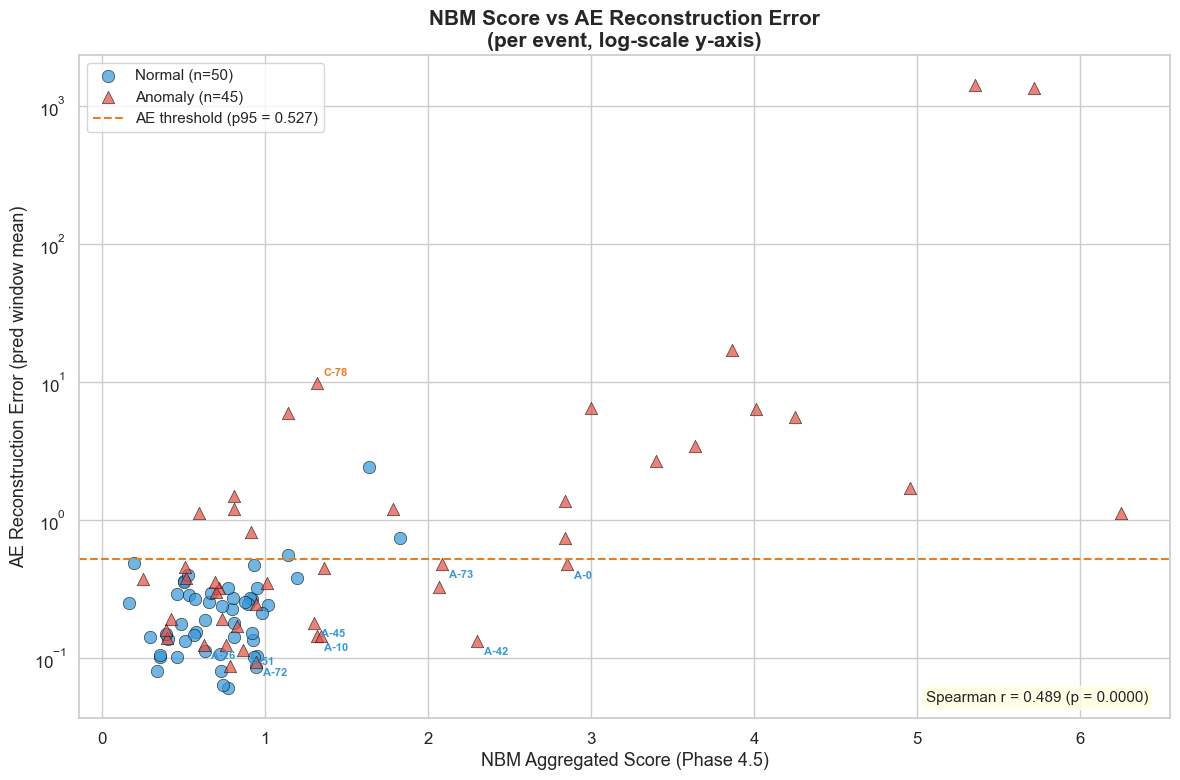


Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\nbm_vs_ae_scatter.png


In [9]:
##############################################################################
# Scatter: NBM agg score vs AE reconstruction error
##############################################################################
fig, ax = plt.subplots(figsize=(12, 8))

scatter_df = df.dropna(subset=["nbm_agg_score", "ae_pred_mean"]).copy()

for label, color, marker in [("normal", "#3498db", "o"), ("anomaly", "#e74c3c", "^")]:
    sub = scatter_df[scatter_df["event_label"] == label]
    ax.scatter(sub["nbm_agg_score"], sub["ae_pred_mean"],
               c=color, marker=marker, s=80, alpha=0.7,
               edgecolors="black", linewidths=0.5,
               label=f"{label.capitalize()} (n={len(sub)})")

# Draw threshold lines
ax.axhline(y=ae_threshold_95, color="#e67e22", linestyle="--", linewidth=1.5,
           label=f"AE threshold (p95 = {ae_threshold_95:.3f})")

# Annotate some key events that only one method catches
ae_only_events = scatter_df[(scatter_df["is_anomaly"] == 1) &
                            (scatter_df["nbm_detected"] == 0) &
                            (scatter_df["ae_detected"] == 1)]
for _, row in ae_only_events.iterrows():
    ax.annotate(f"{row['farm']}-{row['event_id']}",
                (row["nbm_agg_score"], row["ae_pred_mean"]),
                fontsize=8, color="#e67e22", fontweight="bold",
                xytext=(5, 5), textcoords="offset points")

nbm_only_events = scatter_df[(scatter_df["is_anomaly"] == 1) &
                              (scatter_df["nbm_detected"] == 1) &
                              (scatter_df["ae_detected"] == 0)]
for _, row in nbm_only_events.head(8).iterrows():  # limit labels for readability
    ax.annotate(f"{row['farm']}-{row['event_id']}",
                (row["nbm_agg_score"], row["ae_pred_mean"]),
                fontsize=8, color="#3498db", fontweight="bold",
                xytext=(5, -10), textcoords="offset points")

ax.set_xlabel("NBM Aggregated Score (Phase 4.5)", fontsize=13)
ax.set_ylabel("AE Reconstruction Error (pred window mean)", fontsize=13)
ax.set_yscale("log")
ax.set_title("NBM Score vs AE Reconstruction Error\n(per event, log-scale y-axis)", fontsize=15, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")

# Correlation
from scipy.stats import spearmanr
corr, pval = spearmanr(scatter_df["nbm_agg_score"], scatter_df["ae_pred_mean"])
ax.text(0.98, 0.02, f"Spearman r = {corr:.3f} (p = {pval:.4f})",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES / "nbm_vs_ae_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {FIGURES / 'nbm_vs_ae_scatter.png'}")

## 8. Detailed Event-Level Table

Show every anomaly event with both scores, detection status, and which method caught it.

In [10]:
##############################################################################
# Detailed anomaly event table
##############################################################################
detail = anom[["farm", "event_id", "fault_category", "nbm_agg_score",
               "ae_pred_mean", "nbm_detected", "ae_detected"]].copy()

def detection_label(row):
    if row["nbm_detected"] == 1 and row["ae_detected"] == 1:
        return "Both"
    elif row["nbm_detected"] == 1:
        return "NBM only"
    elif row["ae_detected"] == 1:
        return "AE only"
    else:
        return "MISSED"

detail["Detected By"] = detail.apply(detection_label, axis=1)
detail = detail.sort_values(["farm", "event_id"])
detail = detail.rename(columns={
    "farm": "Farm",
    "event_id": "Event",
    "fault_category": "Fault Type",
    "nbm_agg_score": "NBM Score",
    "ae_pred_mean": "AE Error",
    "nbm_detected": "NBM",
    "ae_detected": "AE",
})

print("DETAILED ANOMALY EVENT TABLE (45 events)")
print("=" * 95)
print(detail[["Farm", "Event", "Fault Type", "NBM Score", "AE Error", "Detected By"]].to_string(
    index=False,
    float_format=lambda x: f"{x:.3f}",
))

# Highlight the missed events
missed = detail[detail["Detected By"] == "MISSED"]
print(f"\n*** EVENTS MISSED BY BOTH METHODS ({len(missed)}):")
if len(missed) > 0:
    print(missed[["Farm", "Event", "Fault Type", "NBM Score", "AE Error"]].to_string(index=False))
else:
    print("  None -- at least one method catches every anomaly!")

DETAILED ANOMALY EVENT TABLE (45 events)
Farm  Event          Fault Type  NBM Score  AE Error Detected By
   A      0   Generator Bearing      2.855     0.478    NBM only
   A     10             Gearbox      1.316     0.144    NBM only
   A     22           Hydraulic      2.067     0.329      MISSED
   A     26           Hydraulic      0.625     0.125    NBM only
   A     40   Generator Bearing      6.252     1.119        Both
   A     42           Hydraulic      2.300     0.134    NBM only
   A     45           Hydraulic      1.300     0.180    NBM only
   A     51             Gearbox      0.862     0.114    NBM only
   A     68         Transformer      0.715     0.322      MISSED
   A     72             Gearbox      0.942     0.094    NBM only
   A     73           Hydraulic      2.084     0.485    NBM only
   A     84           Hydraulic      1.342     0.144      MISSED
   B      7         Transformer      0.830     0.171    NBM only
   B     19         Transformer      0.691     0.

## 9. Summary & Recommendations for TDI Weighting

In [11]:
##############################################################################
# Summary table and recommendations
##############################################################################
# Compute per-farm AE separation ratios
ae_farm_sep = {}
for farm in ["A", "B", "C"]:
    f_anom_ae = df[(df["farm"] == farm) & (df["is_anomaly"] == 1)]["ae_pred_mean"].dropna()
    f_norm_ae = df[(df["farm"] == farm) & (df["is_anomaly"] == 0)]["ae_pred_mean"].dropna()
    ae_farm_sep[farm] = f_anom_ae.mean() / f_norm_ae.mean() if f_norm_ae.mean() > 0 else 0

print("=" * 80)
print("SUMMARY: NBM vs LSTM-Autoencoder Comparison")
print("=" * 80)

summary = {
    "Metric": [
        "Overall Detection Rate",
        "Overall False Alarm Rate",
        "Precision",
        "F1 Score",
        "Farm A Detection Rate",
        "Farm B Detection Rate",
        "Farm C Detection Rate",
        "Farm A False Alarm Rate",
        "Farm B False Alarm Rate",
        "Farm C False Alarm Rate",
    ],
    "NBM (LightGBM)": [
        f"{nbm_tp/n_anomaly:.1%}",
        f"{nbm_fp/n_normal:.1%}",
        f"{nbm_tp/(nbm_tp+nbm_fp):.1%}" if (nbm_tp+nbm_fp) > 0 else "N/A",
        f"{combo_df[combo_df['Strategy']=='NBM Only']['F1'].values[0]:.1%}",
    ] + [
        f"{farm_comp_df[farm_comp_df['Farm']==f]['NBM Det. Rate'].values[0]:.1%}" for f in ["A","B","C"]
    ] + [
        f"{farm_comp_df[farm_comp_df['Farm']==f]['NBM FA Rate'].values[0]:.1%}" for f in ["A","B","C"]
    ],
    "LSTM-AE": [
        f"{ae_tp/n_anomaly:.1%}",
        f"{ae_fp/n_normal:.1%}",
        f"{ae_tp/(ae_tp+ae_fp):.1%}" if (ae_tp+ae_fp) > 0 else "N/A",
        f"{combo_df[combo_df['Strategy']=='AE Only']['F1'].values[0]:.1%}",
    ] + [
        f"{farm_comp_df[farm_comp_df['Farm']==f]['AE Det. Rate'].values[0]:.1%}" for f in ["A","B","C"]
    ] + [
        f"{farm_comp_df[farm_comp_df['Farm']==f]['AE FA Rate'].values[0]:.1%}" for f in ["A","B","C"]
    ],
    "Union (Either)": [
        f"{union_tp/n_anomaly:.1%}",
        f"{union_fp/n_normal:.1%}",
        f"{union_tp/(union_tp+union_fp):.1%}" if (union_tp+union_fp) > 0 else "N/A",
        f"{combo_df[combo_df['Strategy']=='Union (OR)']['F1'].values[0]:.1%}",
    ] + [
        f"{farm_comp_df[farm_comp_df['Farm']==f]['Union Det. Rate'].values[0]:.1%}" for f in ["A","B","C"]
    ] + [
        f"{farm_comp_df[farm_comp_df['Farm']==f]['Union FA Rate'].values[0]:.1%}" for f in ["A","B","C"]
    ],
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

# AE separation by farm
print(f"\nAE anomaly/normal mean error ratio by farm:")
for farm, ratio in ae_farm_sep.items():
    print(f"  Farm {farm}: {ratio:.1f}x")

print("\n" + "=" * 80)
print("RECOMMENDATIONS FOR PHASE 6 (TDI WEIGHTING)")
print("=" * 80)
print(f"""
1. PRIMARY METHOD: NBM (LightGBM subsystem residuals)
   - The NBM is the workhorse: {nbm_tp/n_anomaly:.0%} detection rate with established
     subsystem-level interpretability (gearbox, generator bearing, transformer, hydraulic, cooling).
   - Provides subsystem-specific degradation signals needed for TDI component scores.

2. SECONDARY METHOD: LSTM-Autoencoder
   - AE detection rate: {ae_tp/n_anomaly:.0%} -- it complements the NBM by catching
     events that fall through the subsystem-specific residual approach.
   - AE is particularly strong on Farm C (high-dimensional, {ae_farm_sep.get("C", 0):.0f}x separation)
     where it learns cross-feature patterns the per-subsystem NBMs may miss.
   - Weak on Farms A/B where separation ratios are low ({ae_farm_sep.get("A", 0):.1f}x, {ae_farm_sep.get("B", 0):.1f}x).

3. COMBINATION STRATEGY:
   - Union (OR) raises detection to {union_tp/n_anomaly:.0%} but at the cost of
     {union_fp/n_normal:.0%} false alarm rate.
   - Recommended TDI approach: weighted combination with NBM as primary signal.

4. SUGGESTED TDI WEIGHTS:
   - NBM component: 0.70 weight (primary, interpretable, subsystem-level)
   - AE component:  0.30 weight (complementary, cross-feature patterns)
   - When both methods agree on an anomaly, increase confidence score.
   - AE weight could be farm-adaptive: higher for Farm C, lower for A/B.
""")

SUMMARY: NBM vs LSTM-Autoencoder Comparison
                  Metric NBM (LightGBM) LSTM-AE Union (Either)
  Overall Detection Rate          86.7%   42.2%          88.9%
Overall False Alarm Rate          32.0%    6.0%          32.0%
               Precision          70.9%   86.4%          71.4%
                F1 Score          78.0%   56.7%          79.2%
   Farm A Detection Rate          75.0%    8.3%          75.0%
   Farm B Detection Rate          83.3%   33.3%          83.3%
   Farm C Detection Rate          92.6%   59.3%          96.3%
 Farm A False Alarm Rate          10.0%    0.0%          10.0%
 Farm B False Alarm Rate          33.3%   11.1%          33.3%
 Farm C False Alarm Rate          38.7%    6.5%          38.7%

AE anomaly/normal mean error ratio by farm:
  Farm A: 1.9x
  Farm B: 1.4x
  Farm C: 369.6x

RECOMMENDATIONS FOR PHASE 6 (TDI WEIGHTING)

1. PRIMARY METHOD: NBM (LightGBM subsystem residuals)
   - The NBM is the workhorse: 87% detection rate with established
    

## 10. Save Comparison Report

In [12]:
##############################################################################
# Save comparison report JSON
##############################################################################
report = {
    "phase": "5.8",
    "description": "NBM vs LSTM-Autoencoder comparison for anomaly detection",
    "n_events": len(df),
    "n_anomaly": int(n_anomaly),
    "n_normal": int(n_normal),
    "ae_threshold_p95": float(ae_threshold_95),
    "detection_overlap_anomalies": {
        "both_detect": int(both_detect),
        "nbm_only": int(nbm_only),
        "ae_only": int(ae_only),
        "both_miss": int(both_miss),
    },
    "overall_metrics": {
        "nbm": {
            "detection_rate": float(nbm_tp / n_anomaly),
            "false_alarm_rate": float(nbm_fp / n_normal),
            "precision": float(nbm_tp / (nbm_tp + nbm_fp)) if (nbm_tp + nbm_fp) > 0 else 0,
            "f1": float(combo_df[combo_df["Strategy"] == "NBM Only"]["F1"].values[0]),
        },
        "ae": {
            "detection_rate": float(ae_tp / n_anomaly),
            "false_alarm_rate": float(ae_fp / n_normal),
            "precision": float(ae_tp / (ae_tp + ae_fp)) if (ae_tp + ae_fp) > 0 else 0,
            "f1": float(combo_df[combo_df["Strategy"] == "AE Only"]["F1"].values[0]),
        },
        "union_or": {
            "detection_rate": float(union_tp / n_anomaly),
            "false_alarm_rate": float(union_fp / n_normal),
            "precision": float(union_tp / (union_tp + union_fp)) if (union_tp + union_fp) > 0 else 0,
            "f1": float(combo_df[combo_df["Strategy"] == "Union (OR)"]["F1"].values[0]),
        },
        "intersection_and": {
            "detection_rate": float(inter_tp / n_anomaly),
            "false_alarm_rate": float(inter_fp / n_normal),
            "precision": float(inter_tp / (inter_tp + inter_fp)) if (inter_tp + inter_fp) > 0 else 0,
            "f1": float(combo_df[combo_df["Strategy"] == "Intersection (AND)"]["F1"].values[0]),
        },
    },
    "per_farm_metrics": {
        row["Farm"]: {
            "nbm_detection_rate": float(row["NBM Det. Rate"]),
            "ae_detection_rate": float(row["AE Det. Rate"]),
            "union_detection_rate": float(row["Union Det. Rate"]),
            "nbm_false_alarm_rate": float(row["NBM FA Rate"]),
            "ae_false_alarm_rate": float(row["AE FA Rate"]),
            "union_false_alarm_rate": float(row["Union FA Rate"]),
        }
        for _, row in farm_comp_df.iterrows()
    },
    "per_fault_type": [
        {
            "fault_type": row["Fault Type"],
            "n_events": int(row["N"]),
            "nbm_detection_rate": float(row["NBM Rate"]),
            "ae_detection_rate": float(row["AE Rate"]),
            "union_detection_rate": float(row["Union Rate"]),
        }
        for _, row in fault_comp_df.iterrows()
    ],
    "ae_farm_separation_ratios": {k: float(v) for k, v in ae_farm_sep.items()},
    "score_correlation_spearman": float(corr),
    "score_correlation_pvalue": float(pval),
    "recommended_tdi_weights": {
        "nbm_weight": 0.70,
        "ae_weight": 0.30,
        "rationale": "NBM is primary (interpretable, subsystem-level); AE is complementary (cross-feature patterns, strong on high-dimensional Farm C)",
    },
    "figures_saved": [
        "nbm_vs_ae_detection_overlap.png",
        "nbm_vs_ae_per_fault_type.png",
        "nbm_vs_ae_per_farm.png",
        "nbm_vs_ae_score_distributions.png",
        "nbm_vs_ae_combination_strategies.png",
        "nbm_vs_ae_scatter.png",
    ],
}

report_path = REPORTS / "nbm_vs_ae_comparison.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print(f"Saved comparison report: {report_path}")
print(f"\nFigures saved to: {FIGURES}")
print("Done!")

Saved comparison report: D:\Personal Projects\Enbridge Case Compettion\outputs\reports\nbm_vs_ae_comparison.json

Figures saved to: D:\Personal Projects\Enbridge Case Compettion\outputs\figures
Done!
